# 7장 실습 ① — 정확도에 속지 않기

**Keras 3 판**

> *"로스가 작아지면 성능이 좋아지는 거 아닌가요? 예 맞는 말입니다.
> **하지만요.** 로스가 보여주는 성능이 어느 정도인지는 가늠할 수가 없습니다."*

양성이 5%뿐인 데이터로, **정확도만 보면 왜 위험한지**를 확인합니다.

## 7.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '3.15.1', 'tensorflow': '2.21.0', 'torch': '-', 'keras_backend': 'tensorflow'}


## 7.1 불균형 데이터 — 실무의 대부분이 이렇다

불량품 검출, 질병 진단, 사기 거래 탐지 — 찾으려는 것이 드뭅니다.

**먼저 기준선을 잽니다.** 아무것도 안 하는 모델이 몇 점인지 모르면,
모델의 점수를 읽을 수 없습니다.

In [3]:
# 양성이 5%뿐인 데이터를 만든다 — 불량품 검출, 질병 진단, 사기 탐지가 다 이렇다.
rng = np.random.default_rng(0)
x, y = data.spirals(4000, seed=7, noise=0.2)
neg = np.flatnonzero(y == 0)
pos = np.flatnonzero(y == 1)[: int(len(np.flatnonzero(y == 0)) * 0.05)]
sel = np.concatenate([neg, pos]); rng.shuffle(sel)
x, y = x[sel], y[sel]
s = data.split(x, y, val_ratio=0.2, test_ratio=0.2, seed=42)

print(f"전체 {len(x)}개 중 양성 {int(y.sum())}개 ({y.mean():.1%})")
dlbook.record("ch07_positive_ratio", float(y.mean()))

# ★ 기준선 — 아무것도 안 하는 모델의 정확도
baseline = metrics.accuracy(s.y_test, np.zeros(len(s.y_test), dtype=int))
dlbook.record("ch07_baseline_acc", baseline)
print(f"'전부 음성'이라고만 답하는 모델의 정확도: {baseline:.3f}")
print("→ 앞으로 나오는 정확도는 이 값과 견주어 읽으십시오.")

전체 2100개 중 양성 100개 (4.8%)
ch07_positive_ratio = 0.0476
ch07_baseline_acc = 0.9524
'전부 음성'이라고만 답하는 모델의 정확도: 0.952
→ 앞으로 나오는 정확도는 이 값과 견주어 읽으십시오.


## 7.2 모델 — 여기만 판마다 다릅니다

`predict_score()` 가 **이진화하기 전의 점수**를 돌려주는 것에 주목하십시오.
ROC를 그리려면 이 값이 필요합니다.

In [4]:
import keras
from keras import layers

dlbook.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer=keras.optimizers.Adam(0.001), loss="binary_crossentropy")
model.fit(s.x_train, s.y_train, validation_data=(s.x_val, s.y_val),
          epochs=dlbook.smoke.epochs(100), batch_size=32, verbose=0)

def predict_score(xa):
    """이진화하기 **전**의 점수를 돌려준다. ROC에는 이것이 필요하다."""
    return model.predict(xa, verbose=0).reshape(-1)

## 7.3 여러 지표로 재 봅니다

**정확도 하나만 보면 무엇을 놓치는지** 나란히 놓고 보십시오.

In [5]:
score = predict_score(s.x_test)          # 이진화하기 전의 점수
pred = (score > 0.5).astype("int64")

acc = metrics.accuracy(s.y_test, pred)
pr = metrics.precision_recall_f1(s.y_test, pred)
auc = metrics.auc(s.y_test, score)

dlbook.record("ch07_model_acc", acc)
dlbook.record("ch07_model_f1", pr["f1"])
dlbook.record("ch07_model_auc", auc)

print(f"정확도  {acc:.3f}   (기준선 {baseline:.3f} — 겨우 {acc - baseline:+.3f})")
print(f"정밀도  {pr['precision']:.3f}")
print(f"재현율  {pr['recall']:.3f}   ← 실제 양성 중 얼마나 잡았나")
print(f"F1     {pr['f1']:.3f}")
print(f"AUC    {auc:.3f}   ← 문턱값과 무관한 모델 자체의 변별력")
print()
print(metrics.report(s.y_test, pred, ["음성", "양성"]))

ch07_model_acc = 0.9643
ch07_model_f1 = 0.5455
ch07_model_auc = 0.9273
정확도  0.964   (기준선 0.952 — 겨우 +0.012)
정밀도  0.692
재현율  0.450   ← 실제 양성 중 얼마나 잡았나
F1     0.545
AUC    0.927   ← 문턱값과 무관한 모델 자체의 변별력

정확도  0.9643

혼동행렬 (행=실제, 열=예측)
          음성    양성
음성       396     4
양성        11     9

클래스         정밀도      재현율       F1     개수
음성        0.973    0.990    0.981    400
양성        0.692    0.450    0.545     20


## 7.4 혼동행렬 — 실상이 드러나는 곳

**행이 실제, 열이 예측**입니다. 이 방향이 바뀌면 정밀도와 재현율이 뒤집힙니다.

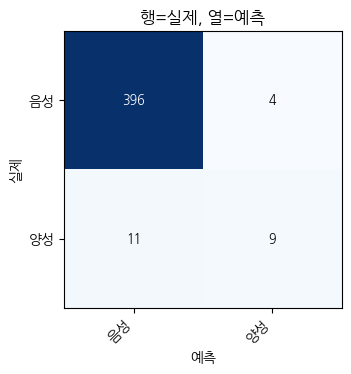

실제 양성 20개 중 9개만 잡았습니다. 11개를 놓쳤습니다.
→ 정확도 0.96이 이 사실을 가려 줍니다.


In [6]:
cm = metrics.confusion_matrix(s.y_test, pred)
plot.confusion(cm, ["음성", "양성"], title="행=실제, 열=예측")
plt.show()

tp, fn = cm[1, 1], cm[1, 0]
print(f"실제 양성 {tp + fn}개 중 {tp}개만 잡았습니다. {fn}개를 놓쳤습니다.")
print("→ 정확도 0.96이 이 사실을 가려 줍니다.")

## 7.5 ROC 곡선과 AUC

문턱값을 1.0에서 0.0까지 훑으며 찍은 점들입니다.
**문턱값을 정하지 않고 모델 자체를 평가**할 수 있습니다.

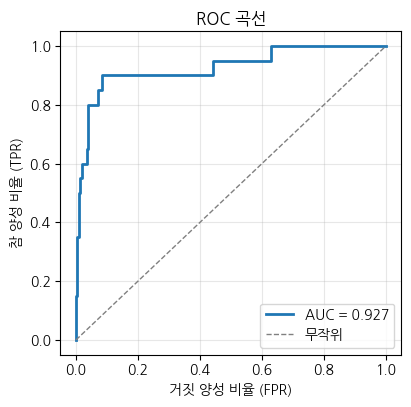

/home/claude/v12/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


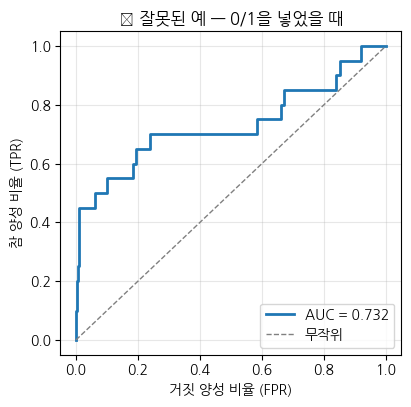

In [7]:
plot.roc(s.y_test, score)
plt.show()

# ✗ 흔한 실수 — 이진화한 값을 넣으면 점이 세 개인 곡선이 나온다
plot.roc(s.y_test, pred, title="✗ 잘못된 예 — 0/1을 넣었을 때")
plt.show()

## 7.6 문턱값 0.5는 그냥 관행입니다

불균형 데이터에서 0.5는 지나치게 보수적입니다. 바꿔 가며 재 봅니다.

In [8]:
print(f"{'문턱값':>8}{'정밀도':>10}{'재현율':>10}{'F1':>10}")
best_t, best_f1 = 0.5, 0.0
for t in (0.05, 0.1, 0.2, 0.3, 0.5, 0.7):
    p = (score > t).astype("int64")
    m = metrics.precision_recall_f1(s.y_test, p)
    if m["f1"] > best_f1:
        best_t, best_f1 = t, m["f1"]
    print(f"{t:>8.2f}{m['precision']:>10.3f}{m['recall']:>10.3f}{m['f1']:>10.3f}")

print()
print(f"→ F1이 가장 높은 문턱값은 {best_t}입니다. 0.5가 아닙니다.")
print("→ ⚠ 다만 이 표를 **시험 데이터**로 만들었습니다. 실무에서는 검증 데이터로")
print("   문턱값을 정하고, 시험 데이터는 마지막에 한 번만 씁니다. (본문 §7.6)")

     문턱값       정밀도       재현율        F1
    0.05     0.305     0.900     0.456
    0.10     0.381     0.800     0.516
    0.20     0.464     0.650     0.542
    0.30     0.579     0.550     0.564
    0.50     0.692     0.450     0.545
    0.70     0.857     0.300     0.444

→ F1이 가장 높은 문턱값은 0.3입니다. 0.5가 아닙니다.
→ ⚠ 다만 이 표를 **시험 데이터**로 만들었습니다. 실무에서는 검증 데이터로
   문턱값을 정하고, 시험 데이터는 마지막에 한 번만 씁니다. (본문 §7.6)


## 정리

- **정확도를 볼 때는 반드시 기준선을 함께 보십시오.**
  '전부 음성'이 0.95를 내는 문제에서 0.96은 자랑할 일이 아닙니다.
- **혼동행렬을 보면 실상이 드러납니다.** 실제 양성의 절반을 놓치고 있었습니다.
- **정밀도와 재현율은 맞바꿈 관계**이고, 무엇이 중요한지는 문제가 정합니다.
- **AUC는 문턱값과 무관한 모델 자체의 변별력**입니다.
  정확도가 무의미해 보여도 AUC가 높으면 문턱값 문제일 수 있습니다.
- **ROC에는 이진화하기 전의 점수를 넣으십시오.**

### 연습

1. 문턱값을 검증 데이터로 정하도록 위 셀을 고치십시오.
   시험 데이터로 정했을 때와 결과가 다릅니까.
2. 양성 비율을 1%로 낮추면 표가 어떻게 달라집니까.
3. 클래스 가중치(`class_weight`)를 주어 학습하면 재현율이 오릅니까.